# CUAD Data Exploration

## Goal

The goal of this notebook is to understand the structure of the CUAD dataset before preprocessing and chunking the contracts.

We will examine:
- the dataset structure
- number of contracts
- contract text
- clause categories and annotations
- document length
- class distribution
- possible data quality issues

This exploration will help us decide how to split and chunk the contracts for modeling.

In [1]:
import json
from pathlib import Path

data_path = Path("../data/data/CUADv1.json")

with open(data_path, "r", encoding="utf-8") as file:
    data = json.load(file)

print("Dataset loaded successfully!")
print("Top-level type:", type(data))

Dataset loaded successfully!
Top-level type: <class 'dict'>


In [2]:
print(data.keys())


dict_keys(['version', 'data'])


In [3]:
contracts = data["data"]

print("Number of contracts:", len(contracts))
print("Type of contracts:", type(contracts))


Number of contracts: 510
Type of contracts: <class 'list'>


In [4]:
print(contracts[0].keys())

dict_keys(['title', 'paragraphs'])


In [5]:
first_contract = contracts[0]

print("Title:", first_contract["title"])
print("Number of paragraphs:", len(first_contract["paragraphs"]))

Title: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
Number of paragraphs: 1


In [6]:
first_paragraph = first_contract["paragraphs"][0]

print("Paragraph keys:", first_paragraph.keys())

Paragraph keys: dict_keys(['qas', 'context'])


In [7]:

qas = first_paragraph["qas"]

print("Number of QAs:", len(qas))
print("First QA keys:", qas[0].keys())

Number of QAs: 41
First QA keys: dict_keys(['answers', 'id', 'question', 'is_impossible'])


In [ ]:
contract_text = first_contract["paragraphs"][0]["context"]

print(contract_text)

In [ ]:

print(json.dumps(contracts[0], indent=2)[:5000])

{
  "title": "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT",
  "paragraphs": [
    {
      "qas": [
        {
          "answers": [
            {
              "text": "DISTRIBUTOR AGREEMENT",
              "answer_start": 44
            }
          ],
          "id": "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name",
          "question": "Highlight the parts (if any) of this contract related to \"Document Name\" that should be reviewed by a lawyer. Details: The name of the contract",
          "is_impossible": false
        },
        {
          "answers": [
            {
              "text": "Distributor",
              "answer_start": 244
            },
            {
              "text": "Electric City Corp.",
              "answer_start": 148
            },
            {
              "text": "Electric City of Illinois L.L.C.",
              "answer_start": 49574
            },
            {
              "text": "Company",
              "answer_start

In [14]:
first_qa = qas[0]

print("Question:", first_qa["question"])
print("ID:", first_qa["id"])
print("Is impossible:", first_qa["is_impossible"])
print("Number of answers:", len(first_qa["answers"]))

Question: Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract
ID: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name
Is impossible: False
Number of answers: 1


In [15]:
print(first_qa["answers"])

[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]


In [16]:
for i, qa in enumerate(qas):
    print(i, "-", qa["question"])

0 - Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract
1 - Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The two or more parties who signed the contract
2 - Highlight the parts (if any) of this contract related to "Agreement Date" that should be reviewed by a lawyer. Details: The date of the contract
3 - Highlight the parts (if any) of this contract related to "Effective Date" that should be reviewed by a lawyer. Details: The date when the contract is effective 
4 - Highlight the parts (if any) of this contract related to "Expiration Date" that should be reviewed by a lawyer. Details: On what date will the contract's initial term expire?
5 - Highlight the parts (if any) of this contract related to "Renewal Term" that should be reviewed by a lawyer. Details: What is the renewal term after the initial term expires? This includes a

In [17]:
qa_counts = []

for contract in contracts:
    paragraphs = contract["paragraphs"]

    total_qas = 0
    for paragraph in paragraphs:
        total_qas += len(paragraph["qas"])

    qa_counts.append(total_qas)

print("Number of contracts:", len(contracts))
print("Minimum QAs:", min(qa_counts))
print("Maximum QAs:", max(qa_counts))
print("Unique QA counts:", sorted(set(qa_counts)))

Number of contracts: 510
Minimum QAs: 41
Maximum QAs: 41
Unique QA counts: [41]


In [18]:
has_answer = 0
no_answer = 0

for contract in contracts:
    for paragraph in contract["paragraphs"]:
        for qa in paragraph["qas"]:
            if qa["is_impossible"]:
                no_answer += 1
            else:
                has_answer += 1

print("Has answer:", has_answer)
print("No answer:", no_answer)
print("Total:", has_answer + no_answer)

Has answer: 6702
No answer: 14208
Total: 20910


In [19]:
category_counts = {}

for contract in contracts:
    for paragraph in contract["paragraphs"]:
        for qa in paragraph["qas"]:

            category = qa["question"].split('"')[1]

            if category not in category_counts:
                category_counts[category] = 0

            if not qa["is_impossible"]:
                category_counts[category] += 1

for category, count in sorted(category_counts.items(),
                              key=lambda x: x[1],
                              reverse=True):
    print(category, ":", count)

Document Name : 510
Parties : 509
Agreement Date : 470
Governing Law : 437
Expiration Date : 413
Effective Date : 390
Anti-Assignment : 374
Cap On Liability : 275
License Grant : 255
Audit Rights : 214
Termination For Convenience : 183
Post-Termination Services : 182
Exclusivity : 180
Renewal Term : 176
Revenue/Profit Sharing : 166
Insurance : 166
Minimum Commitment : 165
Non-Transferable License : 138
Ip Ownership Assignment : 124
Change Of Control : 121
Non-Compete : 119
Notice Period To Terminate Renewal : 111
Uncapped Liability : 111
Covenant Not To Sue : 100
Rofr/Rofo/Rofn : 85
Volume Restriction : 82
Competitive Restriction Exception : 76
Warranty Duration : 75
Irrevocable Or Perpetual License : 70
Liquidated Damages : 61
No-Solicit Of Employees : 59
Affiliate License-Licensee : 59
Joint Ip Ownership : 46
Non-Disparagement : 38
No-Solicit Of Customers : 34
Third Party Beneficiary : 32
Most Favored Nation : 28
Affiliate License-Licensor : 23
Unlimited/All-You-Can-Eat-License : 17


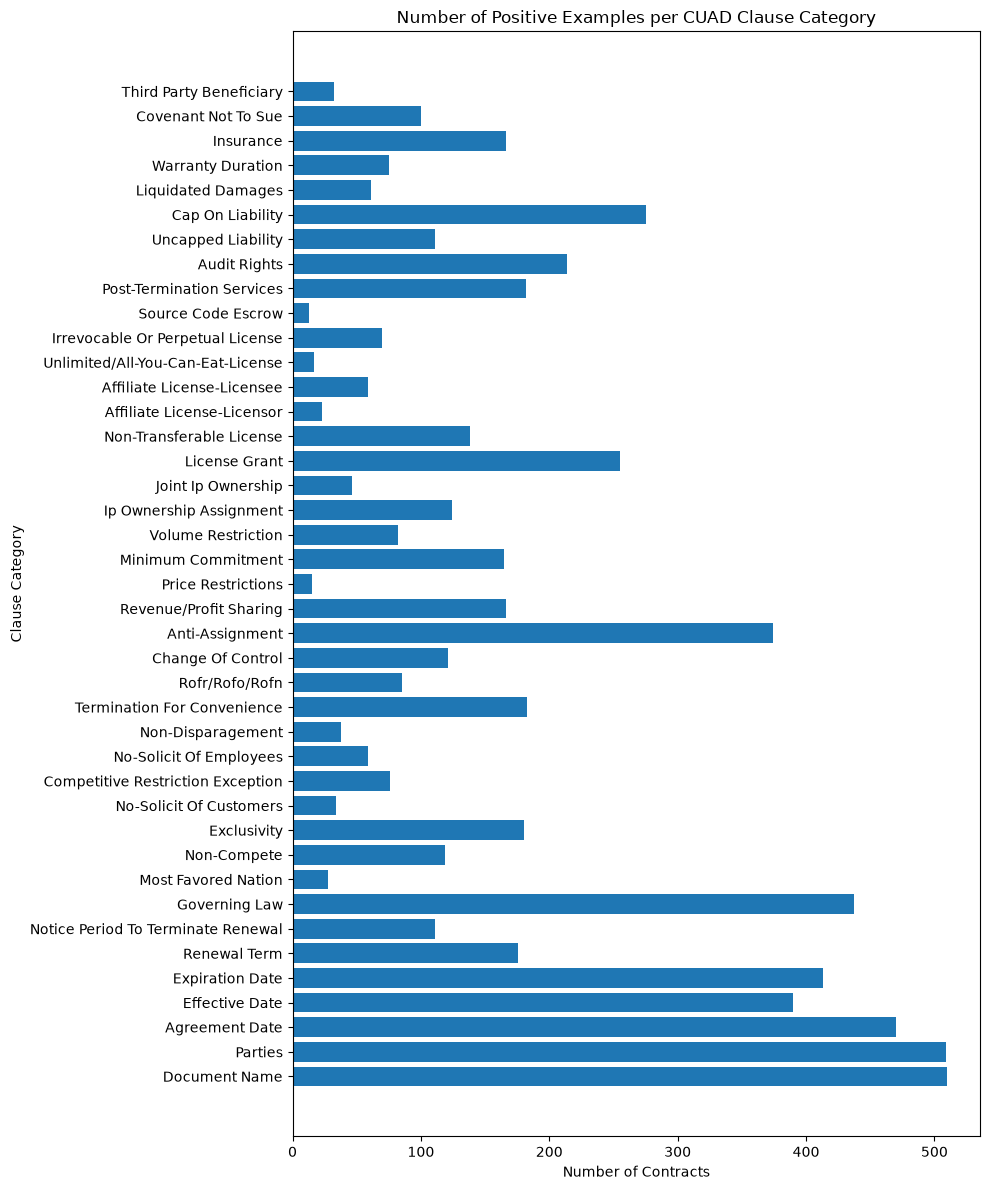

In [20]:
import matplotlib.pyplot as plt

categories = list(category_counts.keys())
counts = list(category_counts.values())

plt.figure(figsize=(10, 12))

plt.barh(categories, counts)

plt.xlabel("Number of Contracts")
plt.ylabel("Clause Category")
plt.title("Number of Positive Examples per CUAD Clause Category")

plt.tight_layout()
plt.show()

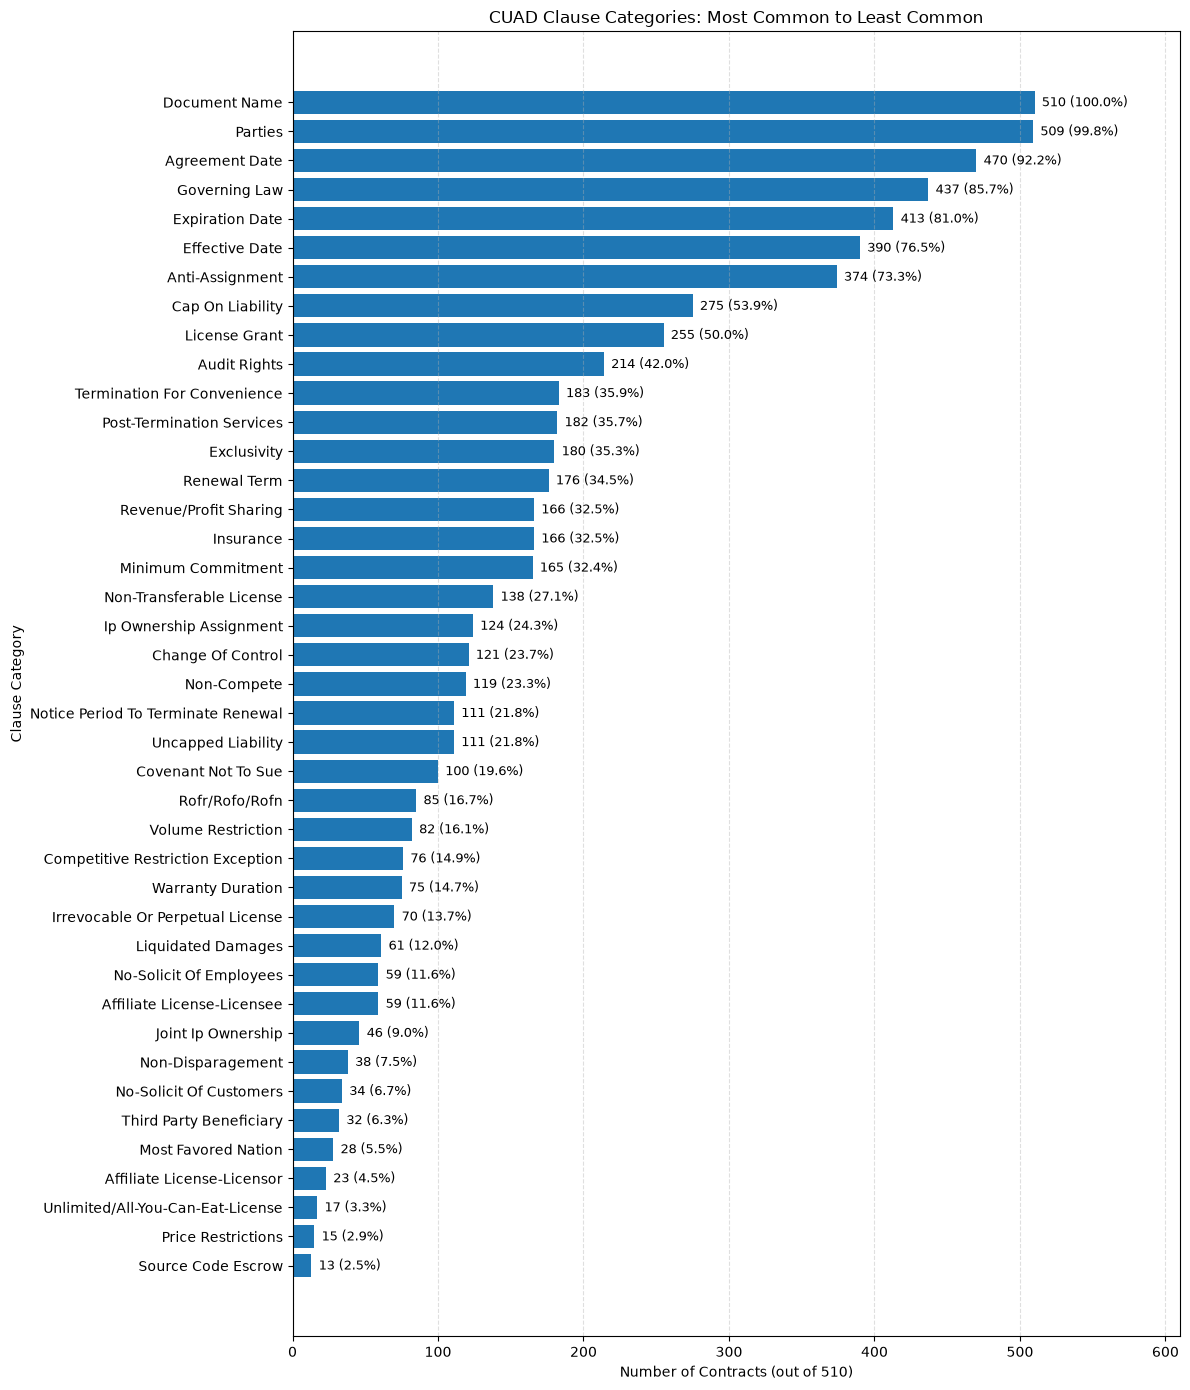

In [21]:
import matplotlib.pyplot as plt

# Sort categories from most common to least common
sorted_categories = sorted(
    category_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

categories = [item[0] for item in sorted_categories]
counts = [item[1] for item in sorted_categories]

total_contracts = len(contracts)

# Make graph larger
plt.figure(figsize=(12, 14))

bars = plt.barh(categories, counts)

# Put most common category at the top
plt.gca().invert_yaxis()

# Add count and percentage beside each bar
for bar, count in zip(bars, counts):
    percentage = (count / total_contracts) * 100

    plt.text(
        count + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percentage:.1f}%)",
        va="center",
        fontsize=9
    )

plt.xlabel("Number of Contracts (out of 510)")
plt.ylabel("Clause Category")
plt.title("CUAD Clause Categories: Most Common to Least Common")

# Makes the numbers easier to compare
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Give room for numbers on the right
plt.xlim(0, max(counts) + 100)

plt.tight_layout()
plt.show()

## Conclusion so far from this Data Exploration

- The dataset contains **510 contracts**.
- Each contract has the same **41 clause categories** that are checked for possible matches.
- There are **20,910 total contract–clause checks** (510 × 41).
- Only **6,702** of these have a matching clause, while **14,208** have no matching clause.
- The clause categories are **not evenly distributed**. Some appear in almost every contract, while others are very rare.
- For example, **Document Name** appears in all 510 contracts, while **Source Code Escrow** appears in only 13.
- This shows that the dataset has a **strong class imbalance**, which we should consider when splitting the data and training/evaluating the model.

